# DE — Regresión con Random Forest

**Materia:** Extracción de Conocimiento de Base de Datos
**Docente:** Filiberto Ruíz Hernández
**Alumno:** Mario Alberto Ramírez Martínez — Matrícula 2023371044
**Universidad:** Universidad Tecnológica de Querétaro — Ingeniería en Gestión de Desarrollo de Software
**Semestre:** 2026 — Fecha: 2026-08-07

---

## 6. Regresión (DE) sobre beisbol.csv

Implementar un algoritmo de regresión alterno al usado en SA (regresión lineal): un Bosque Aleatorio de Regresión (Random Forest Regressor) sobre beisbol.csv, con evaluación y optimización de hiperparámetros.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE = "/home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2"
DATA = os.path.join(BASE, "data/raw")
IMG = os.path.join(BASE, "reporte/img")
MODELOS = os.path.join(BASE, "modelos")
os.makedirs(IMG, exist_ok=True)
os.makedirs(MODELOS, exist_ok=True)
print("Rutas listas: DATA =", DATA)

Rutas listas: DATA = /home/alberto/code/extraccion-conocimiento-bd/evaluacion_u2/data/raw


## Justificación del algoritmo

Se elige **Random Forest Regressor** como alternativa a la regresión lineal de SA. Al ser un ensamble de árboles, puede capturar relaciones no lineales entre `bateos` y `runs` sin asumir una forma paramétrica, y proporciona importancia de variables. Es un algoritmo de regresión de los vistos en clase, robusto frente al ruido y con hiperparámetros claros para optimizar.

In [2]:
df = pd.read_csv(os.path.join(DATA, "beisbol.csv"), index_col=0)
X = df[["bateos"]]
y = df["runs"]
print("Dimensiones:", X.shape)
df.head()

Dimensiones: (30, 1)


,equipos,bateos,runs
0,Texas,5659,855
1,Boston,5710,875
2,Detroit,5563,787
3,Kansas,5672,730
4,St.,5532,762


## Diseño del modelo (paso a paso)

### Estrategia de evaluación con datos escasos

In [3]:
# Igual que en SA: con 30 observaciones se evalúa con validación
# cruzada (LOOCV y k-fold) usando RMSE en lugar de reservar un test pequeño.

## Evaluación y optimización — búsqueda de hiperparámetros

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

grid = {"n_estimators": [50, 100, 200],
        "max_depth": [None, 3, 5],
        "min_samples_leaf": [1, 2, 4]}
gs = GridSearchCV(RandomForestRegressor(random_state=42), grid, cv=5,
                  scoring="neg_root_mean_squared_error", n_jobs=-1)
gs.fit(X, y)
print("Mejores hiperparámetros:", gs.best_params_)
print("Mejor RMSE (CV):", round(-gs.best_score_, 4))

Mejores hiperparámetros: {'max_depth': None, 'min_samples_leaf': 4, 'n_estimators': 50}
Mejor RMSE (CV): 76.2695


### Evaluación del modelo óptimo

In [5]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import cross_val_score, LeaveOneOut

modelo = gs.best_estimator_
y_pred = modelo.predict(X)

print("--- AJUSTE COMPLETO (30 equipos) ---")
print("R2  :", round(r2_score(y, y_pred), 4))
print("RMSE:", round(np.sqrt(mean_squared_error(y, y_pred)), 4))
print("MAE :", round(mean_absolute_error(y, y_pred), 4))
loocv = cross_val_score(modelo, X, y, cv=LeaveOneOut(), scoring="neg_root_mean_squared_error")
print("LOOCV RMSE:", round(-loocv.mean(), 4))
kfold = cross_val_score(modelo, X, y, cv=5, scoring="neg_root_mean_squared_error")
print("5-fold RMSE:", round(-kfold.mean(), 4))

--- AJUSTE COMPLETO (30 equipos) ---
R2  : 0.406
RMSE: 62.498
MAE : 47.5255


LOOCV RMSE: 59.0834


5-fold RMSE: 76.2695


### Gráfica de dispersión del comportamiento de los datos

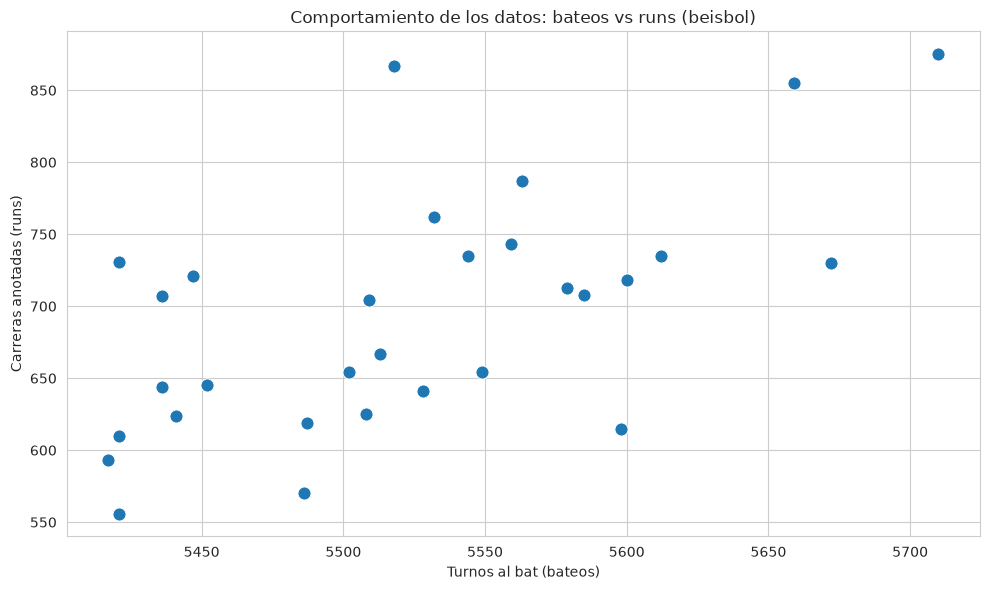

In [6]:
plt.figure()
sns.scatterplot(data=df, x="bateos", y="runs", s=90)
plt.title("Comportamiento de los datos: bateos vs runs (beisbol)")
plt.xlabel("Turnos al bat (bateos)"); plt.ylabel("Carreras anotadas (runs)")
plt.tight_layout()
plt.savefig(os.path.join(IMG, "scatter_beisbol_rf.png"), dpi=150, bbox_inches="tight")
plt.show()

### Gráfica comparativa: valores reales vs predichos

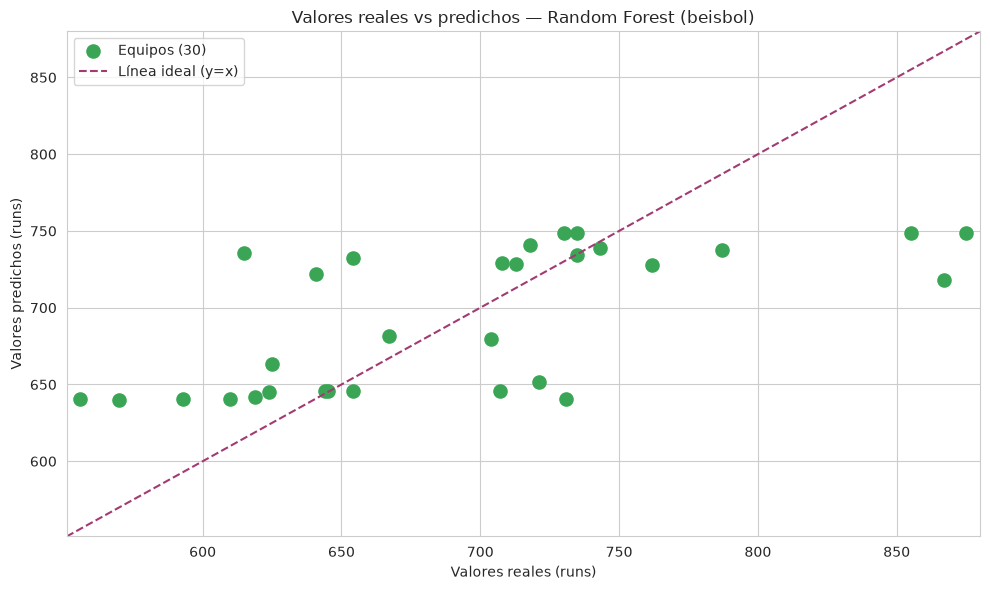

In [7]:
plt.figure()
plt.scatter(y, y_pred, s=90, color="#3AA655", label="Equipos (30)")
lim = [y.min() - 5, y.max() + 5]
plt.plot(lim, lim, "--", color="#A23B72", label="Línea ideal (y=x)")
plt.xlim(lim); plt.ylim(lim)
plt.xlabel("Valores reales (runs)"); plt.ylabel("Valores predichos (runs)")
plt.title("Valores reales vs predichos — Random Forest (beisbol)")
plt.legend(); plt.tight_layout()
plt.savefig(os.path.join(IMG, "reales_predichos_beisbol_rf.png"), dpi=150, bbox_inches="tight")
plt.show()

## Guardar el modelo

In [8]:
import joblib
joblib.dump(modelo, os.path.join(MODELOS, "beisbol_randomforest.pkl"))
print("Modelo guardado en modelos/beisbol_randomforest.pkl")

Modelo guardado en modelos/beisbol_randomforest.pkl


## Verificación de integridad (recarga del modelo)

In [9]:
modelo_cargado = joblib.load(os.path.join(MODELOS, "beisbol_randomforest.pkl"))
y_verif = modelo_cargado.predict(X)
print("R2 tras recargar:", round(r2_score(y, y_verif), 4))
print("Coincide:", np.allclose(y_verif, y_pred))

R2 tras recargar: 0.406
Coincide: True
